In [2]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:100% !important;}
div.cell.code_cell.rendered{width:100%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:20pt;}
div.text_cell_render.rendered_html{font-size:18pt;}
div.text_cell_render.rendered_html{font-size:15pt;}
div.output {font-size:18pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:18pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}

div.text_cell_render ul li{font-size:18pt;padding:5px;}
table.dataframe{font-size:18px;}
</style>
"""))

# 2절. K-Means 클러스터링

In [3]:
import os
os.environ["OMP_NUM_THREADS"] = "1"

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

%config InlineBackend.figure_format='retina'
# 한글설정
plt.rc('font', family='Malgun Gothic')  # 윈도우용
# 경고를 인위적으로 안보이게
plt.rc('axes', unicode_minus=False)


In [7]:
from sklearn.datasets import make_classification

x, y = make_classification(
    n_samples=20,
    n_features=2,
    n_informative=2,
    n_redundant=0,  # 꼭 명시!
    n_classes=2,
    n_clusters_per_class=1,
    random_state=123
)

import numpy as np
print(np.c_[x, y][:3])


[[ 1.03859554  2.51175389  0.        ]
 [ 1.00271366  1.93521549  0.        ]
 [-1.6881048   0.02599427  1.        ]]


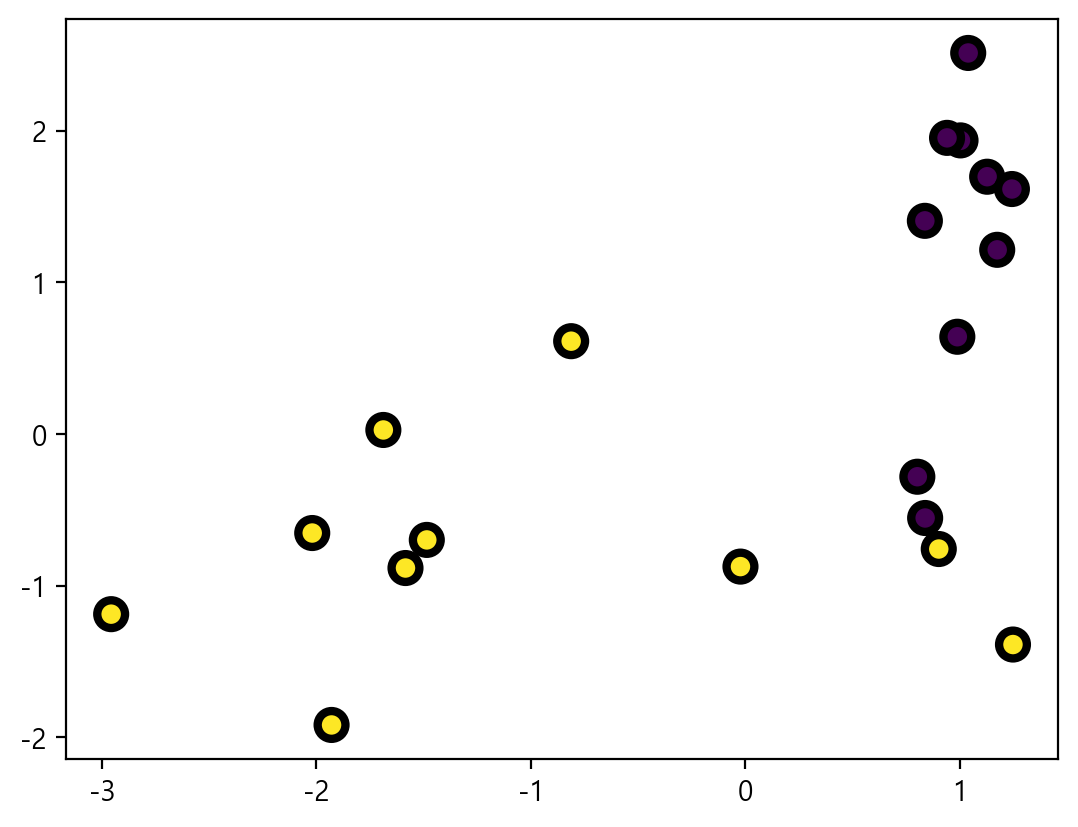

In [9]:
plt.scatter(x=x[:,0], y=x[:,1], c=y, s=100, edgecolors='k', lw=3)
plt.show()

In [10]:
from sklearn.cluster import KMeans
model = KMeans(n_clusters=2,
              init="k-means++",
               n_init=10,
               max_iter=300# random(초기중심점랜덤)
              )
model.fit(x)

KMeans(n_clusters=2, n_init=10)

In [23]:
c0, c1 = model.cluster_centers_ # 모델이 정한 두 중심점
print(c0)
print(c1)

[1.01138251 0.83200493]
[-1.56258716 -0.69768199]


In [24]:
print('modelLabel :', model.labels_)
pred = model.predict(x)
print("  예 측 값 :", pred)
print("  실 제 값 :", y)

modelLabel : [0 0 1 0 0 1 0 1 1 0 0 0 0 1 0 1 1 1 0 0]
  예 측 값 : [0 0 1 0 0 1 0 1 1 0 0 0 0 1 0 1 1 1 0 0]
  실 제 값 : [0 0 1 1 0 1 0 1 1 0 0 0 0 1 1 1 1 1 0 0]


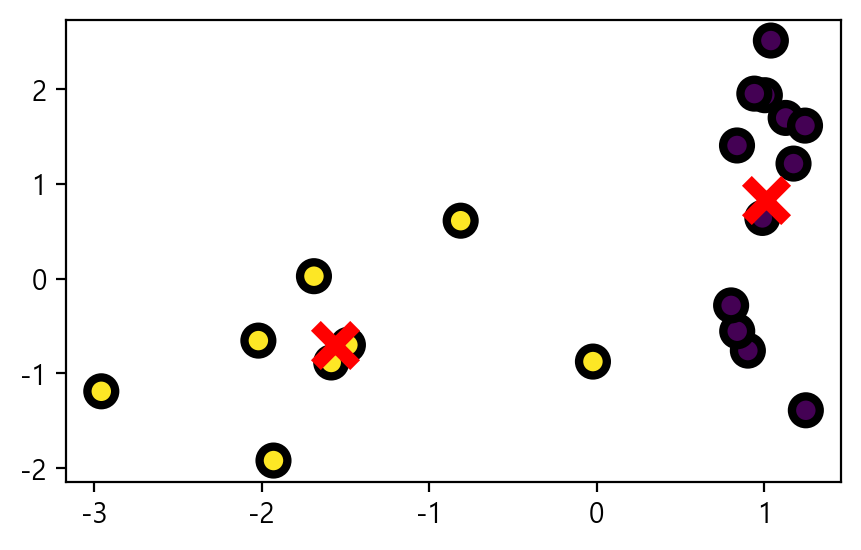

In [25]:
plt.figure(figsize=(5,3))
plt.scatter(x=x[:,0], y=x[:,1], c=pred, s=100, edgecolors='k', lw=3 )
plt.scatter(x=c0[0], y=c0[1], s=200, marker='x', lw=5, c='r')
plt.scatter(x=c1[0], y=c1[1], s=200, marker='x', lw=5, c='r')
plt.show()

## cf nomalizer 이용

In [31]:
import pandas as pd
from sklearn.preprocessing import Normalizer

scaler = Normalizer()
xnor = scaler.fit_transform(x)

np.c_[x, xnor]

array([[ 1.03859554,  2.51175389,  0.3821159 ,  0.92411441],
       [ 1.00271366,  1.93521549,  0.46005267,  0.88789162],
       [-1.6881048 ,  0.02599427, -0.99988146,  0.01539667],
       [ 0.90134424, -0.75896558,  0.76493676, -0.64410538],
       [ 0.83653082,  1.40488232,  0.51161542,  0.85921456],
       [-0.02317631, -0.87481215, -0.02648361, -0.99964925],
       [ 0.83780453, -0.554389  ,  0.83395074, -0.55183889],
       [-1.9295722 , -1.91894047, -0.7090575 , -0.70515067],
       [-0.8124957 ,  0.61140818, -0.79903769,  0.60128094],
       [ 1.12694685,  1.69570061,  0.55350265,  0.83284742],
       [ 0.80138648, -0.28232585,  0.94318094, -0.33227958],
       [ 0.9399586 ,  1.9518949 ,  0.43387458,  0.90097328],
       [ 1.24232232,  1.6146173 ,  0.60980605,  0.79255068],
       [-1.48554751, -0.69890985, -0.90485891, -0.42571159],
       [ 1.24732102, -1.38872822,  0.66821427, -0.74396888],
       [-2.95714561, -1.18843377, -0.92787221, -0.37289833],
       [-1.5849172 , -0.

In [32]:
model = KMeans(n_clusters=2,
              init="k-means++",
               n_init=10,
               max_iter=300# random(초기중심점랜덤)
              )
model.fit(xnor)

KMeans(n_clusters=2, n_init=10)

In [34]:
model.labels_ # 모델이 그룹핑한 결과

array([1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1])

In [ ]:
d0, d1 = model.cluster_centers_ # 모델이 정한 중심점

In [36]:
xnor[model.labers_==0]

AttributeError: 'KMeans' object has no attribute 'labers_'

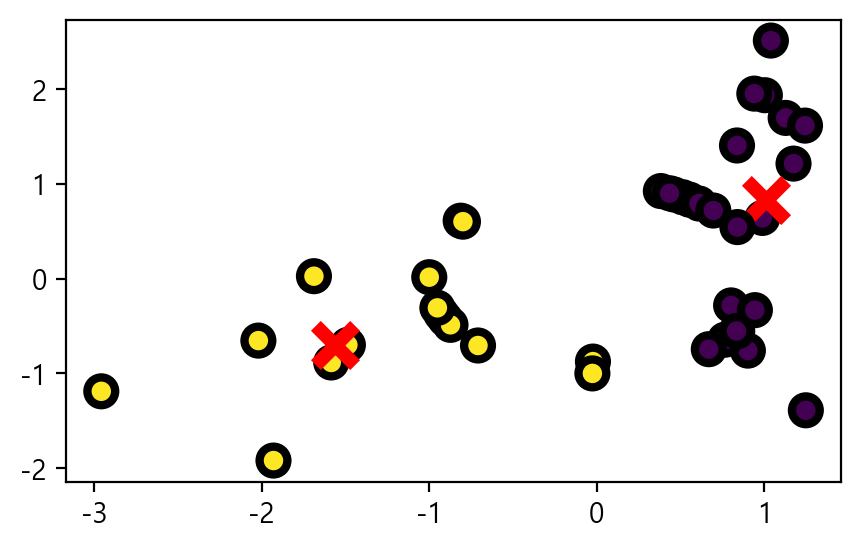

In [35]:
plt.figure(figsize=(5,3))
plt.scatter(x=x[:,0], y=x[:,1], c=pred, s=100, edgecolors='k', lw=3 )
plt.scatter(x=c0[0], y=c0[1], s=200, marker='x', lw=5, c='r')
plt.scatter(x=c1[0], y=c1[1], s=200, marker='x', lw=5, c='r')

plt.scatter(x=xnor[:,0], y=xnor[:,1], c=pred, s=100, edgecolors='k', lw=3 )
plt.show()

## k_Means 클러스터링의 한계점
 - 군의 특성이 다를 경우
      - 크기
      - 군의 밀도
      - 비구형
 - 이상치 포함할 경우 : 이상치를 조정하거나 삭제한 후 클러스터링

In [55]:
import numpy as np
np.random.seed(0)
# 평균:-10, 표준편차:2인 10행 2열 데이터 : group0
group0 = np.random.normal(loc=-10, scale=2, size=(10,2))
y = np.full(group0.shape[0], 0)
group0 = np.c_[group0, y]
group0[:2]

array([[-6.47189531, -9.19968558,  0.        ],
       [-8.04252403, -5.5182136 ,  0.        ]])

In [56]:
# 평균:10, 표준편차:2인 10행 2열 데이터 : group1
group1 = np.random.normal(loc=10, scale=2, size=(10,2))
y = np.full(group1.shape[0], 1)
group1 = np.c_[group1, y]
group1[:2]

array([[ 4.89402037, 11.30723719,  1.        ],
       [11.7288724 ,  8.51566996,  1.        ]])

In [57]:
# 평균:0, 표준편차:5인 100행2열 데이터 : group2
group2 = np.random.normal(loc=0, scale=5, size=(100,2))
y = np.full(group2.shape[0], 2)
group2 = np.c_[group2, y]
group2[:2]

array([[-5.24276483, -7.10008969,  2.        ],
       [-8.53135095,  9.75387698,  2.        ]])

In [64]:
data = np.r_[group0, group1, group2]
data[::10], data.shape


(array([[-6.47189531, -9.19968558,  0.        ],
        [ 4.89402037, 11.30723719,  1.        ],
        [-5.24276483, -7.10008969,  2.        ],
        [-3.36230224, -1.79776581,  2.        ],
        [-5.8257492 ,  4.50413243,  2.        ],
        [ 9.41575349, -6.73879531,  2.        ],
        [ 1.88212766, -5.49700395,  2.        ],
        [-7.45628796,  2.19695851,  2.        ],
        [-2.49016225,  9.64766027,  2.        ],
        [-1.76996956, -6.87475647,  2.        ],
        [-1.84590919, -1.19689589,  2.        ],
        [-4.779725  , -1.72990888,  2.        ]]),
 (120, 3))

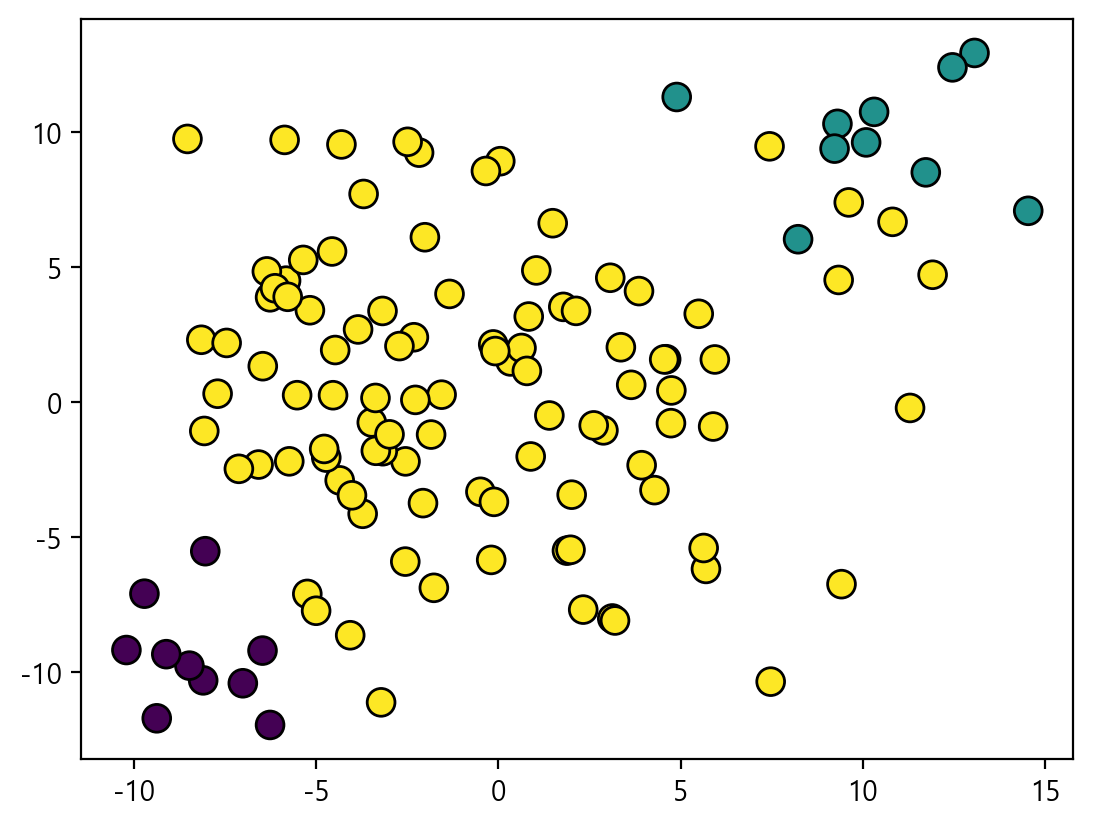

In [65]:
plt.scatter(x=data[:,0], y=data[:,1], c=data[:,2], s=100, edgecolors='k')
plt.show()

In [66]:
model = KMeans(n_clusters=3,
              init="k-means++",
              n_init="auto",
              max_iter=300)
model.fit(data[:, :2])

KMeans(n_clusters=3, n_init='auto')

In [67]:
c = model.cluster_centers_ # 중심점
c

array([[-3.23795138,  3.79797742],
       [ 7.93234415,  5.526175  ],
       [-2.11638402, -5.40013046]])

In [68]:
pred = model.predict(data[:, :2]) # 모델이 클러스터링한 결과
pred = model.labels_

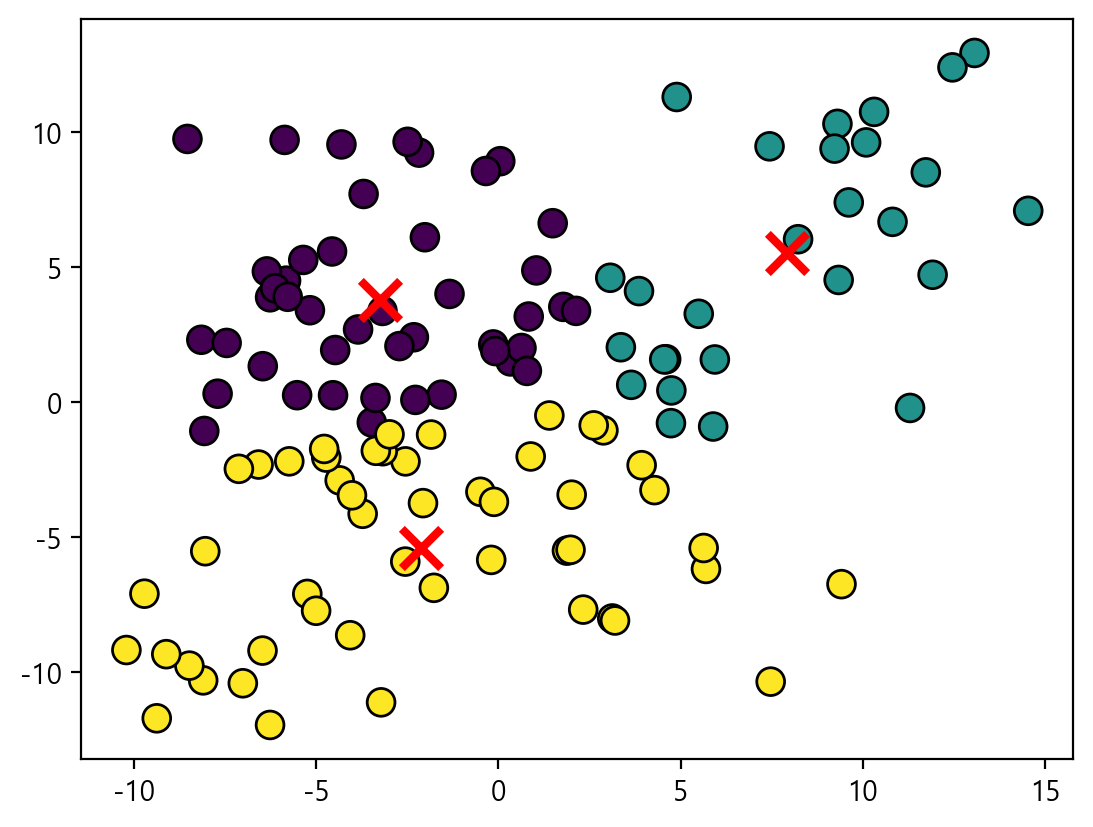

In [69]:
plt.scatter(x=data[:,0], y=data[:,1], c=pred, s=100, edgecolors='k')
plt.scatter(x=c[:,0], y=c[:,1], c='r', marker='x', s=200, lw=3)
plt.show()

In [70]:
model = KMeans(n_clusters=6, init="k-means++", n_init=10)
model.fit(data[:, :2])

KMeans(n_clusters=6, n_init=10)

In [71]:
c = model.cluster_centers_ # 중심점
pred = model.labels_  # 모델이 클러스터한 결과
pred

array([3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 0,
       4, 0, 4, 4, 1, 5, 5, 4, 4, 3, 1, 4, 4, 5, 1, 1, 4, 4, 0, 1, 2, 5,
       0, 0, 5, 5, 0, 5, 1, 0, 0, 4, 2, 2, 0, 0, 5, 5, 1, 5, 4, 0, 5, 4,
       4, 0, 5, 1, 4, 5, 2, 0, 4, 0, 4, 1, 1, 4, 0, 5, 0, 3, 5, 5, 1, 0,
       4, 4, 1, 3, 1, 4, 0, 4, 1, 5, 5, 2, 4, 5, 1, 1, 5, 5, 1, 4, 5, 5,
       4, 4, 4, 5, 4, 4, 4, 0, 1, 5])

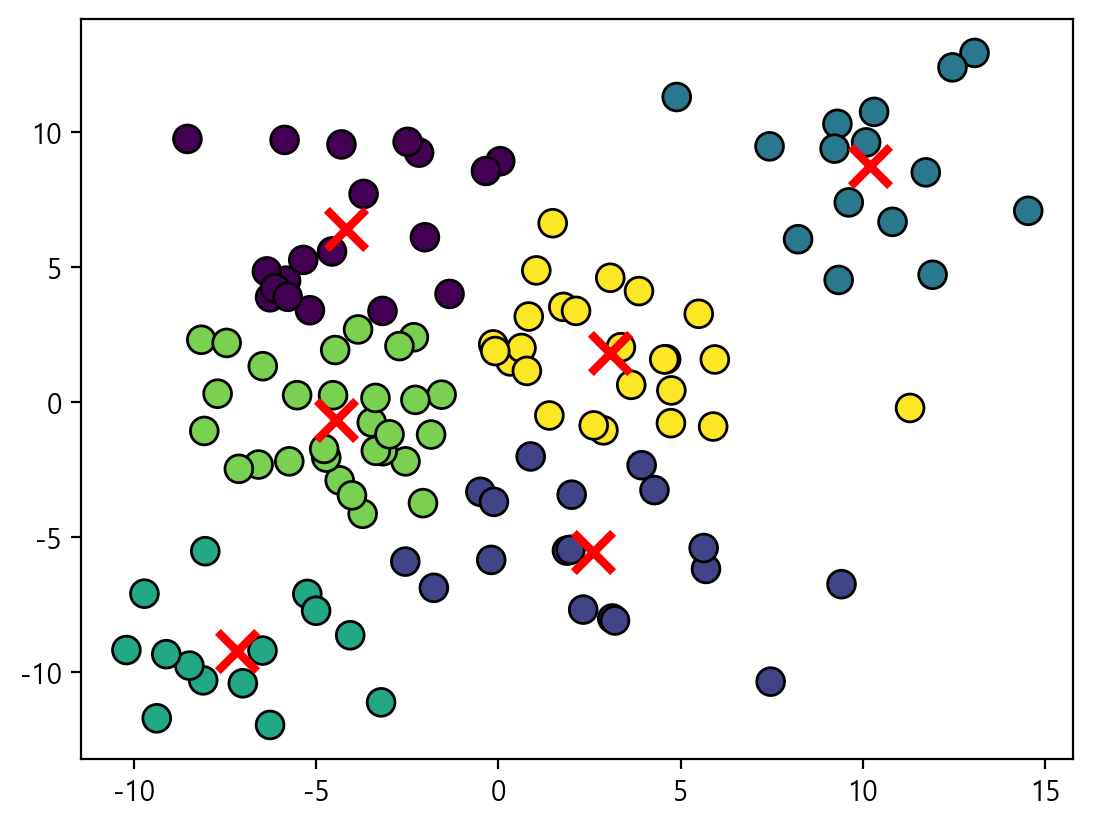

In [72]:
plt.scatter(x=data[:,0], y=data[:,1], c=pred, s=100, edgecolors='k')
plt.scatter(x=c[:,0], y=c[:,1], c='r', marker='x', s=200, lw=3)
plt.show()

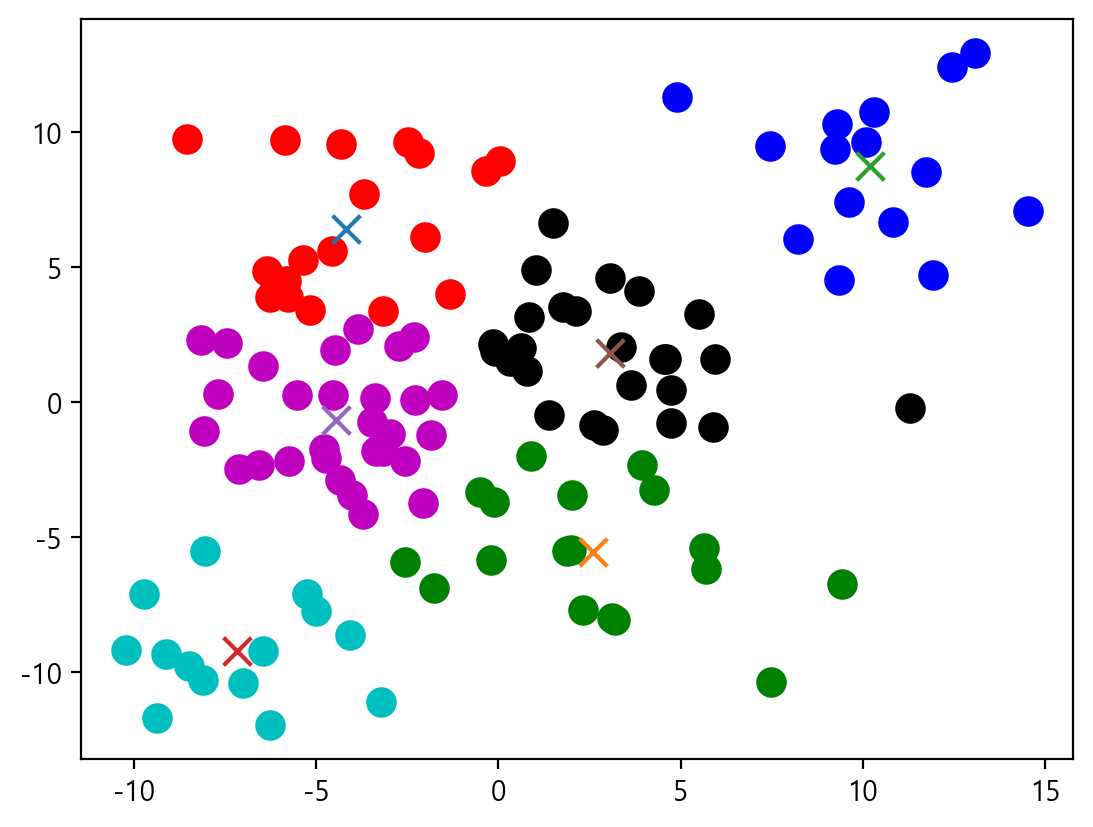

In [75]:

colors = ['r','g','b','c','m','k'] # 0 / 2 / 1345
for i in range(len(c)):
    plt.scatter(x=data[pred==i, 0], y=data[pred==i, 1], c=colors[i], s=100)
    plt.scatter(x=c[i, 0], y=c[i, 1], marker='x', s=100)

# 3절 hierachical 클러스터링 
 - 계증적 분석 -> 덴드로그램 -> f클러스터를 이용해서 군집화
 - 군끼리 묶으면서 최종적으로 하나의 군집이 될 때까지 묶는 클러스터링
 - 군집의 수를 미리 정해주지 않음
 - 군집간의 거리 기반으로 클러스터링

In [77]:
import seaborn as sns
iris = sns.load_dataset('iris')
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [78]:
# 계층적 군집 적용을 위해 라벨 인코딩
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
iris['species'] = le.fit_transform(iris.species)

In [81]:
iris[::50]

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0
50,7.0,3.2,4.7,1.4,1
100,6.3,3.3,6.0,2.5,2


In [82]:
from scipy.cluster.hierarchy import linkage
# method : 거리계산을 어떻게 할지
# method = complete : 두 클러스터에서 가장 먼거리를 이용
# average : 두 클러스터내의 각 점에서 다른 클러스터의 모든 점의 평균거리를 이용
# single : 가장 먼 거리르 이용
cluster_model = linkage(iris, method='complete')

In [83]:
from scipy.cluster.hierarchy import dendrogram
dendrogram(cluster_model, lavels=iris.index)
plt.savefig('')

In [84]:
from scipy.cluster.hierarchy import fcluster # 군집화
fcluster(cluster_model, t=4,
        criterion='distance')

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 3, 2, 2, 2, 2, 3, 2, 2, 2,
       2, 3, 2, 3, 3, 2, 2, 2, 2, 3, 2, 3, 2, 3, 2, 2, 3, 3, 2, 2, 2, 2,
       2, 3, 3, 2, 2, 2, 3, 2, 2, 2, 3, 2, 2, 2, 3, 2, 2, 3], dtype=int32)

In [85]:
fcluster(cluster_model,
        t=3,
        criterion='maxclust')
# maxclust 일때 t 값은 클러스터 갯수(군집화 된 그룹 갯수)

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 3, 2, 2, 2, 2, 3, 2, 2, 2,
       2, 3, 2, 3, 3, 2, 2, 2, 2, 3, 2, 3, 2, 3, 2, 2, 3, 3, 2, 2, 2, 2,
       2, 3, 3, 2, 2, 2, 3, 2, 2, 2, 3, 2, 2, 2, 3, 2, 2, 3], dtype=int32)

In [86]:
fcluster(cluster_model, 5, criterion='distance')

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2], dtype=int32)

# dbscan 클러스터링
- 연결기반(밀도기반) 군집화 알고리즘
- 딩잠 : 클러스터 밀도가 일정하지 않으면 성능 낮아짐

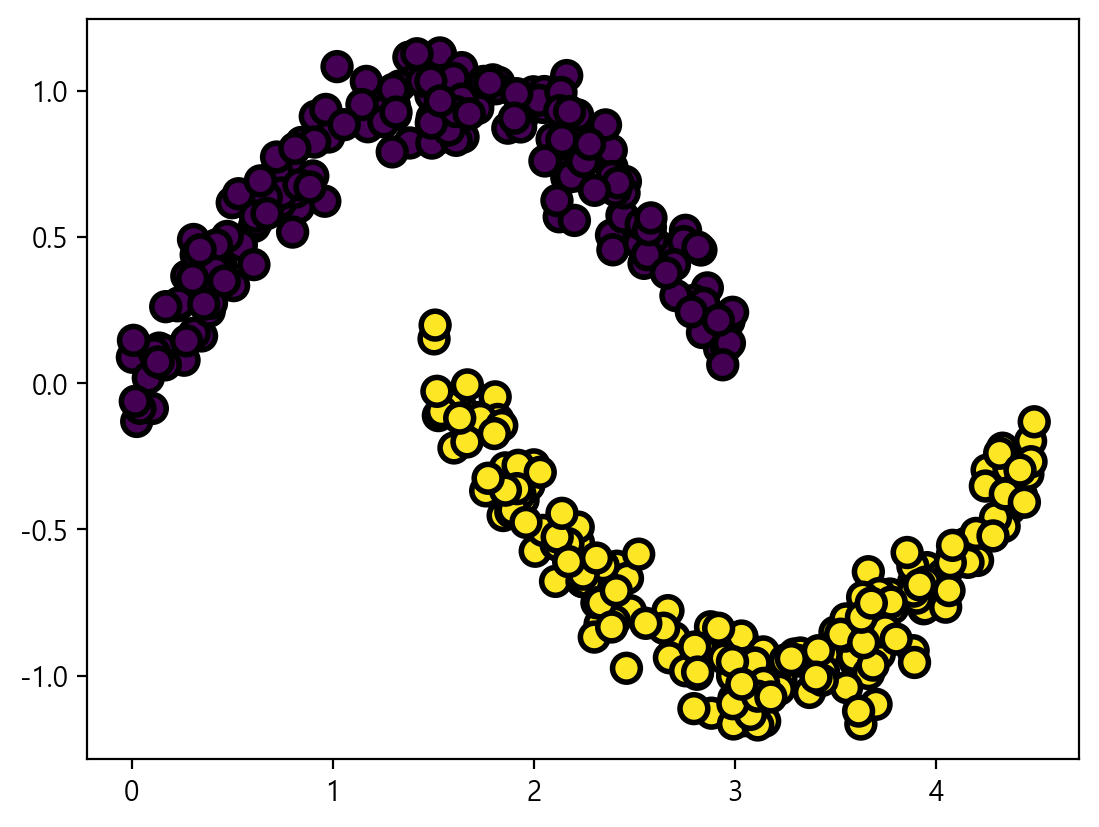

In [98]:
x1 = np.random.rand(200)*3
noise = np.random.normal(0,0.1,200)
y1 = np.sin(x1) + noise
group1 = np.c_[x1, y1, np.full(200,0)]
group1

x2 = x1 + 1.5
y2 = np.cos(x2) + noise
group2 = np.c_[x2, y2, np.full(200, 1)]
data = np.r_[group1, group2]
plt.scatter(data[:,0], data[:,1], c=data[:,2], s=100, edgecolors='k', lw=2)

In [101]:
from sklearn.cluster import DBSCAN
db = DBSCAN(eps=0.3, min_samples=10)
db.fit(data[:, :2])

DBSCAN(eps=0.3, min_samples=10)

In [103]:
db.labels_

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

In [108]:
labels = db.labels_   # 모델이 군집화한 결과 (-1은  이상치 인식)
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)  # 클러스터 수
n_noise_ = list(labels).count(-1)
print(n_clusters_, n_noise_)

2 0


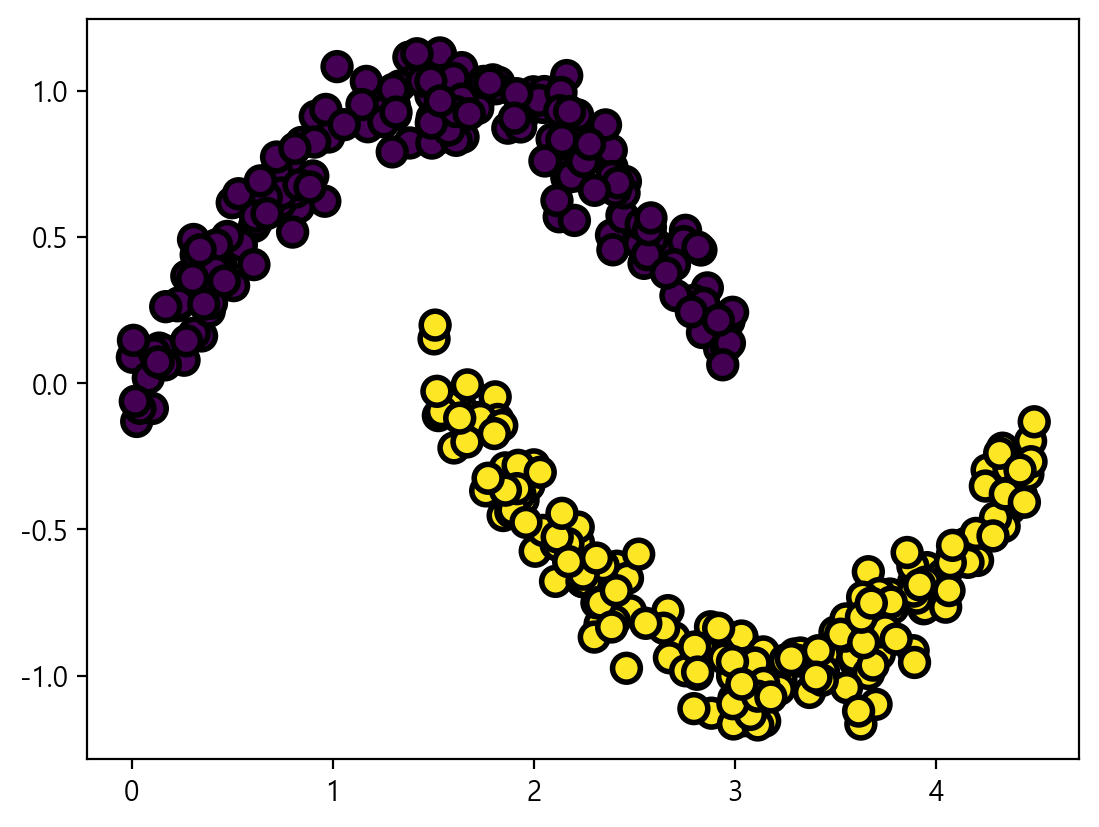

In [109]:
plt.scatter(data[:,0], data[:,1], c=labels, s=100, edgecolors='k', lw=2)

# 5절 모형 성능평가
 - score 메소드를 통해 예측 모형 평가
 - metrics 모듈의 메소드를 통해 군집 모형 평가

In [110]:
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [111]:
iris.sample()

,sepal_length,sepal_width,petal_length,petal_width,species
39,5.1,3.4,1.5,0.2,0


In [112]:
iris_x = iris.iloc[:,:-1]
iris_y = iris.iloc[:,-1]
iris_x.shape, iris_y.shape

((150, 4), (150,))

In [113]:
iris_model3 = KMeans(n_clusters=3, n_init=10, random_state=1)
iris_model3.fit(iris_x)

KMeans(n_clusters=3, n_init=10, random_state=1)

In [114]:
# pred를 조절하기 위해서 
np.choose([3,2,2,3], [0,10,20,30])

array([30, 20, 20, 30])

In [118]:
pred3 = np.choose(iris_model3.labels_, [1,0,2])
pred3 # 조정된 예측값

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 2, 2, 2, 2, 1, 2, 2, 2,
       2, 2, 2, 1, 1, 2, 2, 2, 2, 1, 2, 1, 2, 1, 2, 2, 1, 1, 2, 2, 2, 2,
       2, 1, 2, 2, 2, 2, 1, 2, 2, 2, 1, 2, 2, 2, 1, 2, 2, 1])

In [119]:
# 3개 cluster로 군집화한 자료
print('실제값 :', iris_y[::50])
print('예측값 :', pred3[::50])

실제값 : 0      0
50     1
100    2
Name: species, dtype: int32
예측값 : [0 1 2]


In [123]:
iris_model2 = KMeans(n_clusters=2, n_init=10, random_state=1)
iris_model2.fit(iris_x)

KMeans(n_clusters=2, n_init=10, random_state=1)

In [124]:
pred2 = iris_model2.labels_

In [125]:
# 2개 cluster로 군집화한 자료
iris_y2 = np.array([0]*50 + [1]*100)
print('실제값 : ', iris_y2)

실제값 :  [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1]


In [128]:
# 클러스터가 3개인 경우 평가
from sklearn.metrics import adjusted_mutual_info_score
adjusted_mutual_info_score(labels_true=iris_y,
                          labels_pred=pred3)

0.7551191675800483

In [131]:
# 클러스터가 2개인 경우 평가
adjusted_mutual_info_score(labels_true=iris_y2,
                 labels_pred=pred2)

0.8697005952535362

In [132]:
from sklearn.metrics import mutual_info_score   # 상호 의존도를 나타내는 지표
# 클러스터가 3개인 경우 평가
mutual_info_score(iris_y, pred3)

0.8255910976103356

In [ ]:
# 클러스터가 2개인 경우 평가
mutual_info_score(iris_y2. pred2)

In [133]:
from sklearn.metrics import v_measure_score
v_measure_score(iris_y, pred3)

0.7581756800057784

In [134]:
v_measure_score(iris_y2, pred2)

0.870385156563164

## 실루엣 계수

In [ ]:
x1 = np.random.rand(200)*3
noise = np.random.normal(0,0.1,200)
y1 = np.sin(x1) + noise
group1 = np.c_[x1, y1, np.full(200,0)]
group1

x2 = x1 + 1.5
y2 = np.cos(x2) + noise
group2 = np.c_[x2, y2, np.full(200, 1)]
data = np.r_[group1, group2]
plt.scatter(data[:,0], data[:,1], c=data[:,2], s=100, edgecolors='k', lw=2)

In [141]:
from sklearn.metrics import silhouette_score
range_n_clusters = [2, 3, 4, 5, 6, 7, 8, 9, 10]
for n_clusters in range_n_clusters:
    model = KMeans(n_clusters=n_clusters,
                  n_init=10, 
                  random_state=2)
    model.fit(data[:, :-1])
    score = silhouette_score(X=data[:,:-1],
                            labels=model.labels_)
    print("클러스트수 : {}, 실루엣 계수 : {}".format(n_clusters, score))
# 실루엣 계수가 가장 높은 6개로 클러스터링 할 예정

클러스트수 : 2, 실루엣 계수 : 0.5194231572067918
클러스트수 : 3, 실루엣 계수 : 0.48398050600070897
클러스트수 : 4, 실루엣 계수 : 0.5179504840390479
클러스트수 : 5, 실루엣 계수 : 0.541708005854492
클러스트수 : 6, 실루엣 계수 : 0.5432168699005675
클러스트수 : 7, 실루엣 계수 : 0.5378790081026995
클러스트수 : 8, 실루엣 계수 : 0.5366316187405126
클러스트수 : 9, 실루엣 계수 : 0.5393250744498279
클러스트수 : 10, 실루엣 계수 : 0.5476846763861714


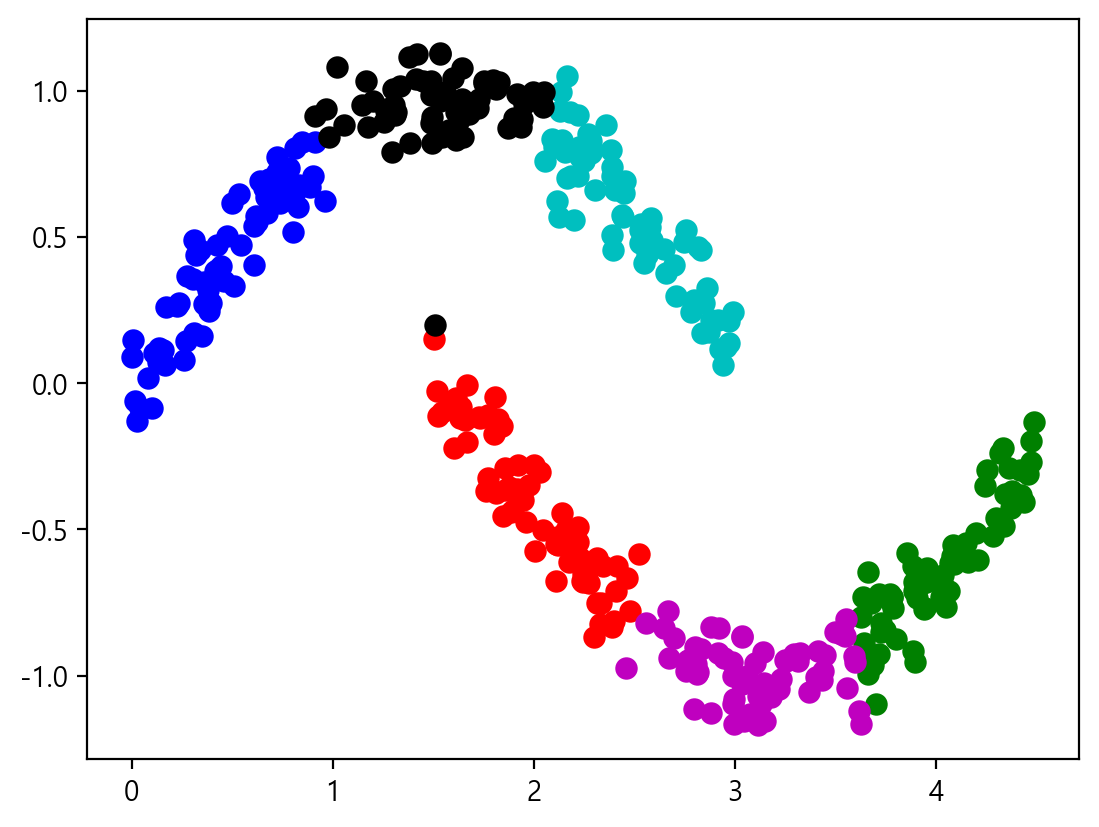

In [145]:
model = KMeans(n_clusters=6, n_init=10, init="k-means++")
model.fit(data[:,:-1])
centers = model.cluster_centers_
colors = ['r','g','b','c','m','k']
for i in range(len(colors)):
    plt.scatter(data[model.labels_==i,0],
                data[model.labels_==i,1],
                c=colors[i], s=50 )